In [1]:
import pandas as pd
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
pd.set_option("display.max_rows", 999)
pd.set_option('max_colwidth',100)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sezen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
emails = pd.read_csv('emails150MB.csv', sep=',', header=None, names=['Folder', 'Email'])

In [3]:
emails.head()

,Folder,Email
0,stokley-c/chris_stokley/projects/ees_/brenda_herod/6.,"Message-ID: <32295689.1075858519201.JavaMail.evans@thyme>\nDate: Sun, 22 Jul 2001 16:29:07 -0700..."
1,stokley-c/chris_stokley/projects/ees_/ercot/1.,"Message-ID: <11422706.1075858518802.JavaMail.evans@thyme>\nDate: Tue, 24 Jul 2001 08:19:57 -0700..."
2,stokley-c/chris_stokley/projects/ees_/ercot/10.,"Message-ID: <24333819.1075858519016.JavaMail.evans@thyme>\nDate: Wed, 1 Aug 2001 06:07:35 -0700 ..."
3,stokley-c/chris_stokley/projects/ees_/ercot/11.,"Message-ID: <17082846.1075858519041.JavaMail.evans@thyme>\nDate: Mon, 30 Jul 2001 18:04:46 -0700..."
4,stokley-c/chris_stokley/projects/ees_/ercot/2.,"Message-ID: <16514884.1075858518826.JavaMail.evans@thyme>\nDate: Tue, 24 Jul 2001 18:01:37 -0700..."


In [4]:
emails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59235 entries, 0 to 59234
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Folder  59235 non-null  object
 1   Email   59235 non-null  object
dtypes: object(2)
memory usage: 925.7+ KB


In [5]:
emails.loc[emails.index==1,'Email']

1    Message-ID: <11422706.1075858518802.JavaMail.evans@thyme>\nDate: Tue, 24 Jul 2001 08:19:57 -0700...
Name: Email, dtype: object

In [3]:
def extract_email_components(email):
    email_dict = {}
    
    message_id_match = re.search(r'Message-ID: (.+)', email)
    email_dict['Message-ID'] = message_id_match.group(1).strip() if message_id_match else np.nan
    
    date_match = re.search(r'Date: (.+)', email)
    email_dict['Date'] = date_match.group(1).strip() if date_match else np.nan
    
    from_match = re.search(r'From: (.+)', email)
    email_dict['From'] = from_match.group(1).strip() if from_match else np.nan
    
    # Check both 'To' and 'X-To' fields, if to field is empty, take x-to field
    to_match = re.search(r'To: (.+)', email)
    x_to_match = re.search(r'X-To: (.+)', email)
    email_dict['To'] = to_match.group(1).strip() if to_match else (x_to_match.group(1).strip() if x_to_match else np.nan)
    
    subject_match = re.search(r'Subject: (.+)', email)
    email_dict['Subject'] = subject_match.group(1).strip() if subject_match else np.nan
    
    cc_match = re.search(r'Cc: (.+)', email)
    email_dict['Cc'] = cc_match.group(1).strip() if cc_match else np.nan
    
    body_start = email.find('\n\n') + 2
    email_dict['Body'] = email[body_start:].strip() if body_start > 1 else np.nan
    
    return email_dict

email_components = emails['Email'].apply(extract_email_components)
email_df = pd.DataFrame(email_components.tolist())

# Add the Folder column to the new DataFrame
email_df['Folder'] = emails['Folder']


In [7]:
email_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59235 entries, 0 to 59234
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message-ID  59235 non-null  object
 1   Date        59235 non-null  object
 2   From        59235 non-null  object
 3   To          56885 non-null  object
 4   Subject     58175 non-null  object
 5   Cc          15282 non-null  object
 6   Body        59235 non-null  object
 7   Folder      59235 non-null  object
dtypes: object(8)
memory usage: 3.6+ MB


In [8]:
email_df.loc[email_df['To'].isnull()].head(2)

,Message-ID,Date,From,To,Subject,Cc,Body,Folder
886,<15037080.1075851728012.JavaMail.evans@thyme>,"Wed, 14 Feb 2001 08:00:00 -0800 (PST)",amanda.huble@enron.com,NaN,West Pipeline Scraping/Weekly Status Meeting in EB32C2,NaN,"With Hunter, Colin, Chris Gaskill, Keith Holst, & Jay Reitmeyer",storey-g/all_documents/13.
899,<19809205.1075851728355.JavaMail.evans@thyme>,"Thu, 8 Mar 2001 04:00:00 -0800 (PST)",amanda.huble@enron.com,NaN,Fundamental Status Meeting in EB3271,NaN,"with Hunter, Chris G., and Colin.",storey-g/all_documents/25.


In [9]:
email_df[['Folder']].head(20)

,Folder
0,stokley-c/chris_stokley/projects/ees_/brenda_herod/6.
1,stokley-c/chris_stokley/projects/ees_/ercot/1.
2,stokley-c/chris_stokley/projects/ees_/ercot/10.
3,stokley-c/chris_stokley/projects/ees_/ercot/11.
4,stokley-c/chris_stokley/projects/ees_/ercot/2.
5,stokley-c/chris_stokley/projects/ees_/ercot/3.
6,stokley-c/chris_stokley/projects/ees_/ercot/4.
7,stokley-c/chris_stokley/projects/ees_/ercot/5.
8,stokley-c/chris_stokley/projects/ees_/ercot/6.
9,stokley-c/chris_stokley/projects/ees_/ercot/7.


In [4]:
max_depth = email_df['Folder'].apply(lambda x: len(x.split('/'))).max()
max_depth

np.int64(6)

In [5]:
def split_folder_path(folder_path, max_depth):
    parts = folder_path.split('/')
    return parts + [None] * (max_depth - len(parts))

folder_levels = email_df['Folder'].apply(lambda x: split_folder_path(x, max_depth)).apply(pd.Series)
folder_levels.columns = [f'Level_{i+1}' for i in range(max_depth)]
email_df = email_df.join(folder_levels)

In [6]:
print(email_df['Level_3'].nunique())
print(email_df['Level_4'].nunique())
print(email_df['Level_5'].unique())
print(email_df['Level_6'].unique())

5353
902
['brenda_herod' 'ercot' 'info' 'intr_month_book' 'metering_and_forcasting'
 'neil_b_' 'todd_busby' '1.' '2.' '3.' '4.' '10.' '11.' '12.' '13.' '14.'
 '15.' '16.' '17.' '18.' '19.' '20.' '21.' '22.' '23.' '24.' '25.' '26.'
 '27.' '28.' '29.' '30.' '31.' '32.' '33.' '5.' '6.' '7.' '8.' '9.' None]
['6.' '1.' '10.' '11.' '2.' '3.' '4.' '5.' '7.' '8.' '9.' '12.' '13.'
 '14.' '15.' '16.' '17.' '18.' '19.' '20.' '21.' '22.' '23.' '24.' '25.'
 '26.' '27.' None]


In [7]:
stemmer = PorterStemmer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize and stop words
    tokens = [word for word in text.split() if word not in stop_words and not word.isnumeric()]
    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

email_df['Processed_Body'] = email_df['Body'].apply(preprocess_text)
email_df['Processed_Subject'] = email_df['Subject'].apply(preprocess_text)


In [14]:
email_df.head(2)

,Message-ID,Date,From,To,Subject,Cc,Body,Folder,Level_1,Level_2,Level_3,Level_4,Level_5,Level_6,Processed_Body,Processed_Subject
0,<32295689.1075858519201.JavaMail.evans@thyme>,"Sun, 22 Jul 2001 16:29:07 -0700 (PDT)",f..herod@enron.com,"kenny.ha@enron.com, chris.stokley@enron.com",FW: Metered Usage,"vivian.hart@enron.com, patti.thompson@enron.com","As part of Project Ranger, it is my goal to have a single repository to house all actual data, a...",stokley-c/chris_stokley/projects/ees_/brenda_herod/6.,stokley-c,chris_stokley,projects,ees_,brenda_herod,6.,part project ranger goal singl repositori hous actual data allow user access data ad hoc report ...,fw meter usag
1,<11422706.1075858518802.JavaMail.evans@thyme>,"Tue, 24 Jul 2001 08:19:57 -0700 (PDT)",preston.ochsner@enron.com,"chris.stokley@enron.com, george.phillips@enron.com",Settlements - What we've done in CA and what we should do in ERCOT,"gary.nelson@enron.com, jeffrey.miller@enron.com, joseph.wagner@enron.com,",EB640,stokley-c/chris_stokley/projects/ees_/ercot/1.,stokley-c,chris_stokley,projects,ees_,ercot,1.,eb640,settlement weve done ca ercot


In [8]:
# Count unique folders at each level
unique_folders_level_1 = email_df['Level_1'].nunique()
unique_folders_level_2 = email_df['Level_2'].nunique()
unique_folders_level_3 = email_df['Level_3'].nunique()
unique_folders_level_4 = email_df['Level_4'].nunique()
unique_folders_level_5 = email_df['Level_5'].nunique()

(unique_folders_level_1, unique_folders_level_2, unique_folders_level_3, unique_folders_level_4, unique_folders_level_5)


(23, 285, 5353, 902, 40)

In [9]:
email_df['Date'] = pd.to_datetime(email_df['Date'], errors='coerce')
# Create new features
email_df['Subject_Length'] = email_df['Processed_Subject'].apply(len)
email_df['Body_Length'] = email_df['Processed_Body'].apply(len)
email_df['Num_Recipients'] = email_df['To'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)
email_df['Has_Cc'] = email_df['Cc'].apply(lambda x: 1 if pd.notna(x) else 0)

email_df['Date'] = pd.to_datetime(email_df['Date'], errors='coerce')
# Extract year, month, and day of the week from the Date column
email_df['Year'] = email_df['Date'].dt.year
email_df['Month'] = email_df['Date'].dt.month
email_df['DayOfWeek'] = email_df['Date'].dt.dayofweek
email_df['YearMonth'] = email_df['Date'].dt.to_period('M')

C:\Users\sezen\AppData\Local\Temp\ipykernel_30404\572588532.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  email_df['Date'] = pd.to_datetime(email_df['Date'], errors='coerce')
C:\Users\sezen\AppData\Local\Temp\ipykernel_30404\572588532.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  email_df['Date'] = pd.to_datetime(email_df['Date'], errors='coerce')
C:\Users\sezen\AppData\Local\Temp\ipykernel_30404\572588532.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  email_df['YearMonth'] = email_df['Date'].dt.to_period('M')


In [10]:
email_df[['Subject_Length', 'Body_Length', 'Num_Recipients', 'Has_Cc']].describe()


,Subject_Length,Body_Length,Num_Recipients,Has_Cc
count,59235.000000,59235.000000,59235.000000,59235.000000
mean,19.568515,930.306761,1.814991,0.257989
std,12.310634,2556.495327,7.078999,0.437532
min,0.000000,0.000000,0.000000,0.000000
25%,11.000000,153.000000,1.000000,0.000000
50%,18.000000,375.000000,1.000000,0.000000
75%,27.000000,884.000000,2.000000,1.000000
max,63.000000,163165.000000,232.000000,1.000000


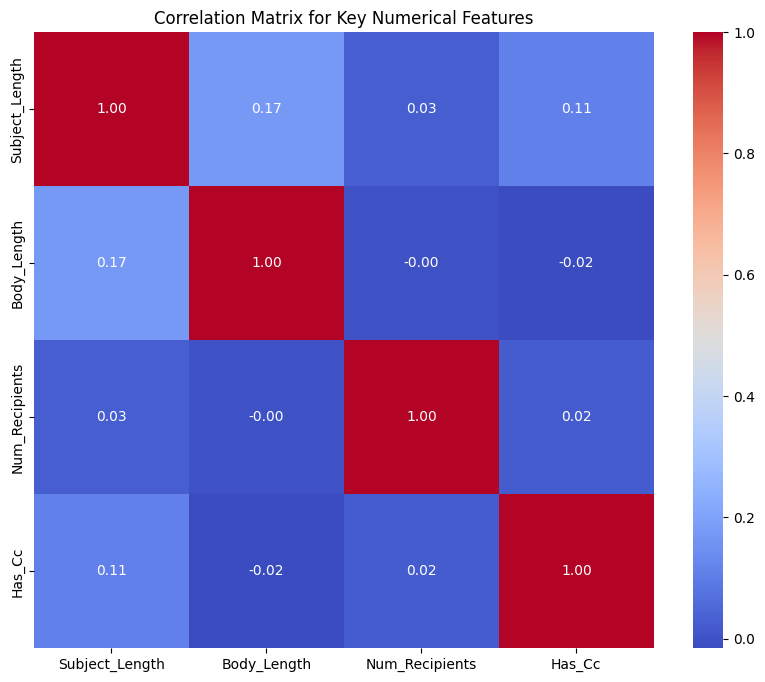

In [18]:
# Compute the correlation matrix for key numerical features
correlation_matrix = email_df[['Subject_Length', 'Body_Length', 'Num_Recipients', 'Has_Cc']].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix for Key Numerical Features')
plt.show()

There are some weak correlations and they are negligible.

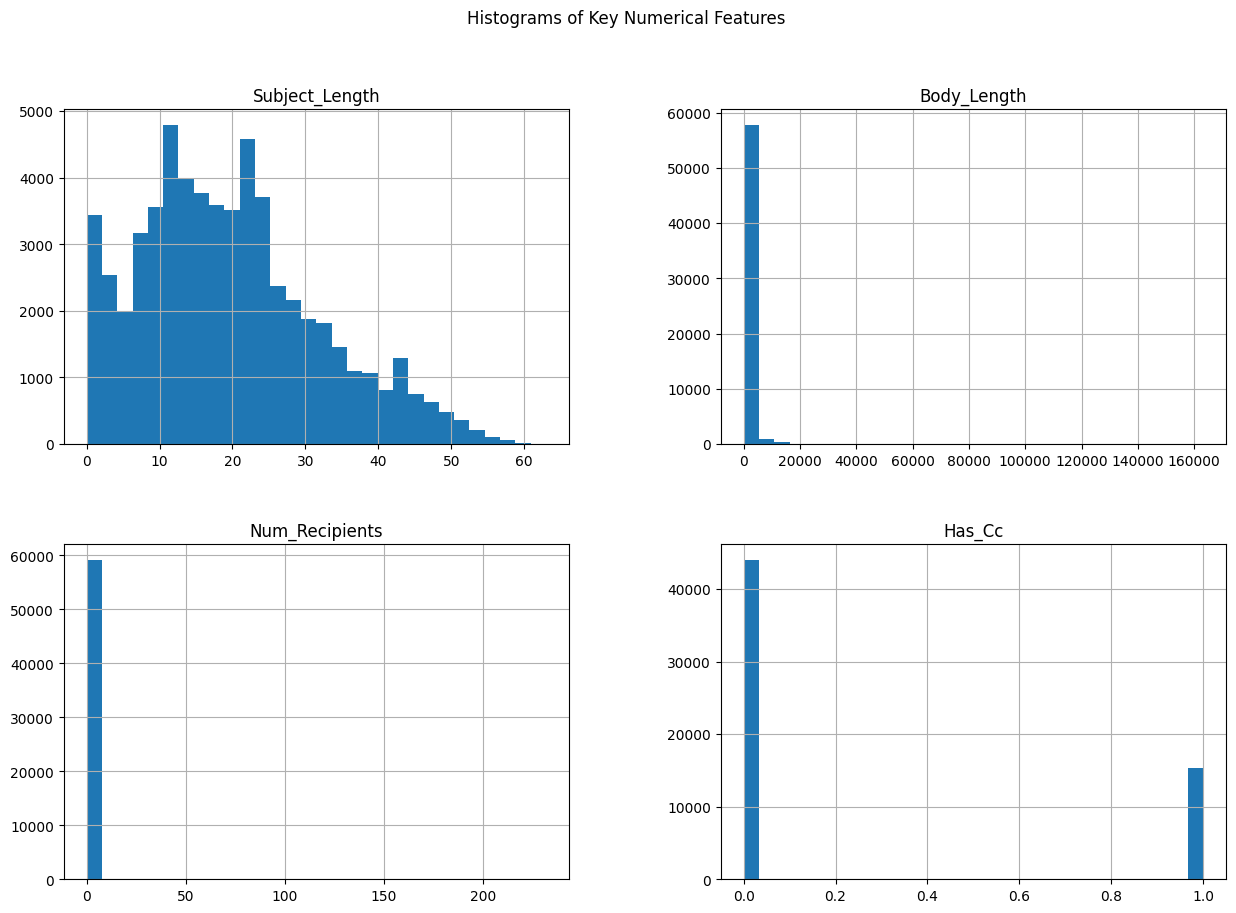

In [19]:
email_df[['Subject_Length', 'Body_Length', 'Num_Recipients', 'Has_Cc']].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Key Numerical Features')
plt.show()

In [11]:
email_df['Body_Length'].value_counts().sort_index()

Body_Length
0         67
1          2
2         27
3         50
4         93
          ..
78857      1
105411     1
122840     2
139822     2
163165     1
Name: count, Length: 4414, dtype: int64

In [21]:
email_df['Num_Recipients'].value_counts()

Num_Recipients
1      41881
4       8298
2       3990
3       2443
0       2350
5        100
223       22
219       12
221       11
143        9
6          8
73         7
19         7
10         7
95         6
32         6
21         6
11         5
8          5
12         5
20         5
93         4
23         4
71         3
7          3
24         3
207        3
141        2
139        2
9          2
25         2
27         2
18         2
14         2
13         2
211        1
51         1
34         1
54         1
68         1
31         1
124        1
70         1
232        1
40         1
76         1
209        1
16         1
22         1
33         1
38         1
Name: count, dtype: int64

Body length distribution is highly skewed. Most emails have relatively short bodies.There are outliers with body length exceeding 20k characters.

Number of Recepients are concentrated around 1, with a few outliers having more recipients.

Most of the emails do not have CC recipients

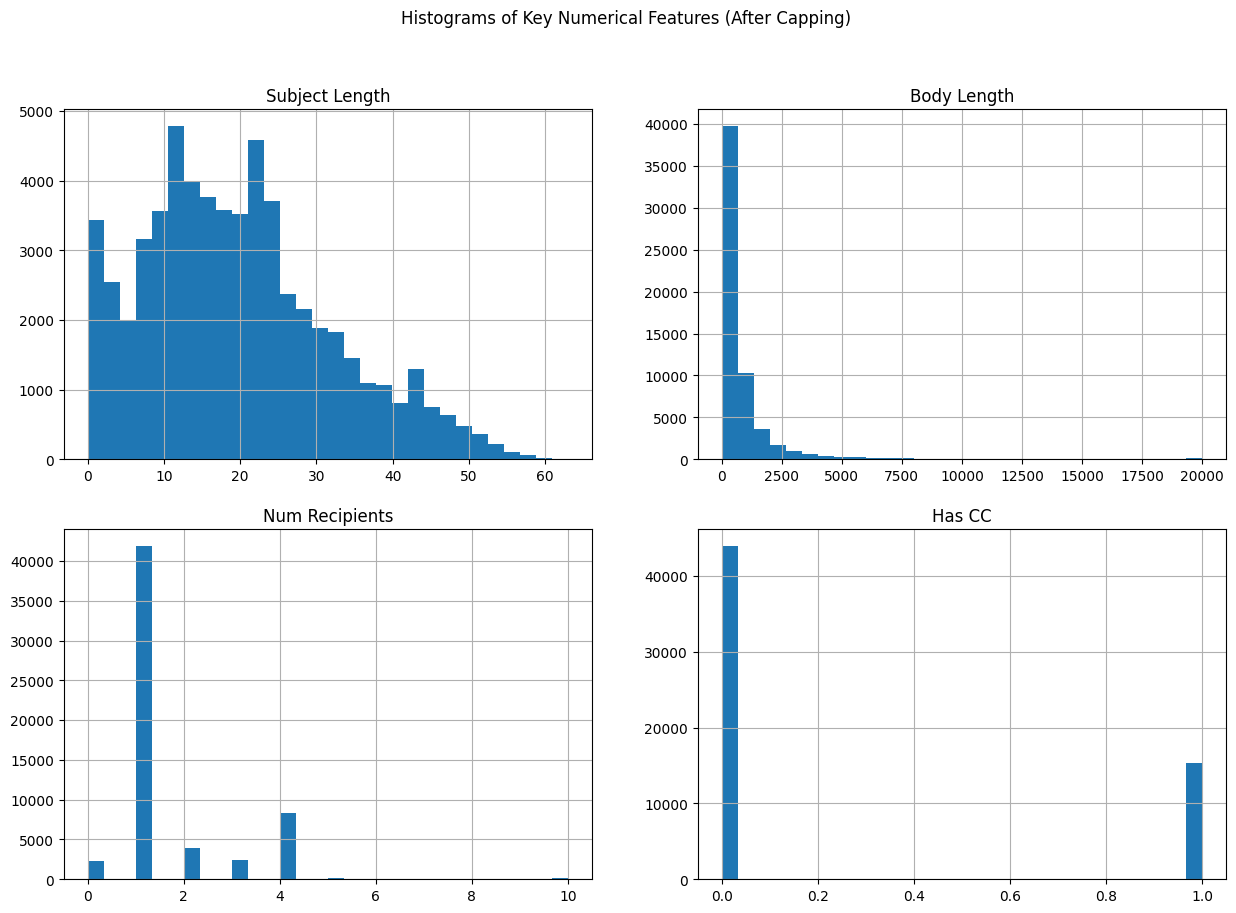

In [22]:
# Cap the number of recipients to a maximum value
email_df['Num_Recipients'] = email_df['Num_Recipients'].apply(lambda x: min(x, 10))

# Cap the body length to a maximum value
email_df['Body_Length'] = email_df['Body_Length'].apply(lambda x: min(x, 20000))

# Plot the updated histograms for Num_Recipients and Body_Length after capping
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
email_df['Subject_Length'].hist(bins=30)
plt.title('Subject Length')

plt.subplot(2, 2, 2)
email_df['Body_Length'].hist(bins=30)
plt.title('Body Length')

plt.subplot(2, 2, 3)
email_df['Num_Recipients'].hist(bins=30)
plt.title('Num Recipients')

plt.subplot(2, 2, 4)
email_df['Has_Cc'].hist(bins=30)
plt.title('Has CC')

plt.suptitle('Histograms of Key Numerical Features (After Capping)')
plt.show()


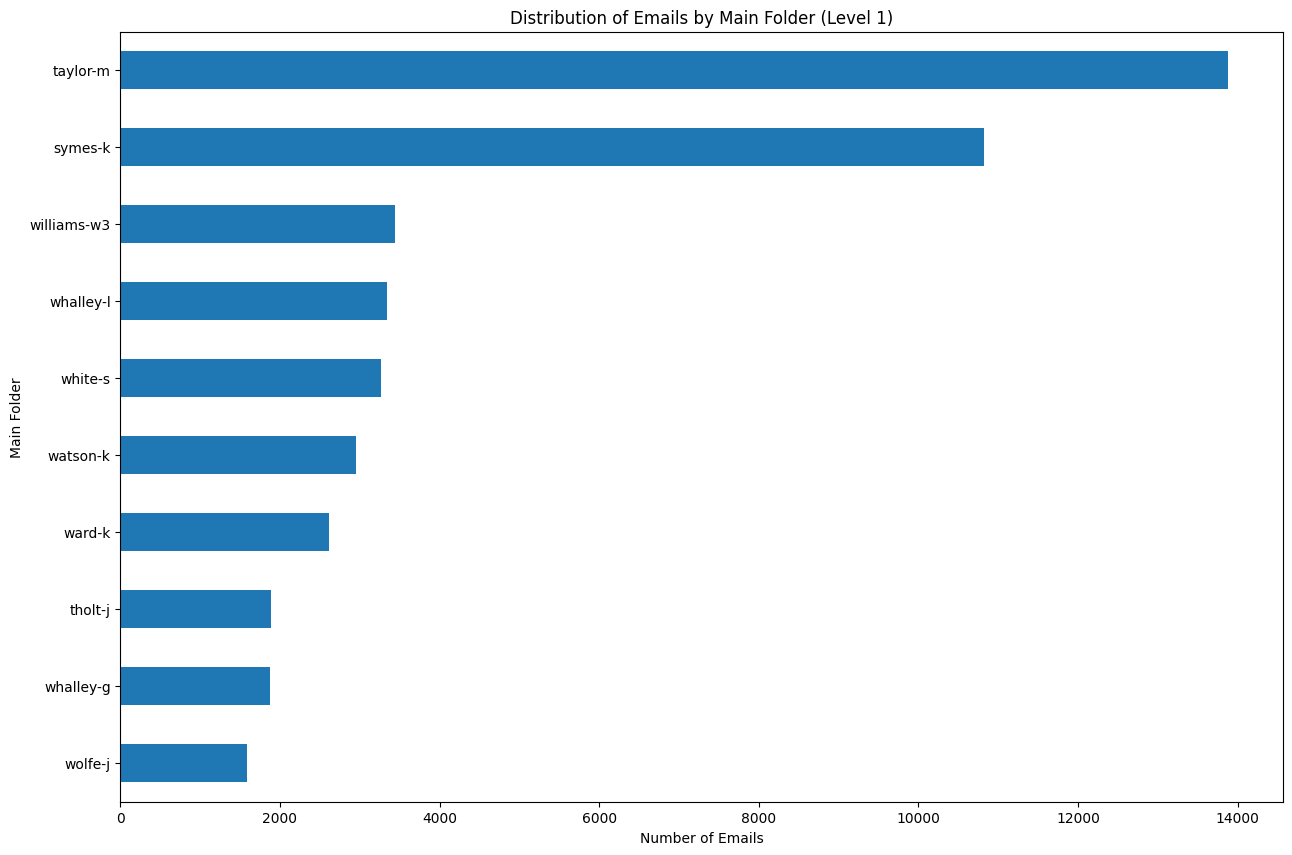

In [23]:
# Distribution by main folder (Level 1)
level_1_distribution = email_df['Level_1'].value_counts()

plt.figure(figsize=(15, 10))
level_1_distribution.head(10).plot(kind='barh')
plt.title('Distribution of Emails by Main Folder (Level 1)')
plt.xlabel('Number of Emails')
plt.ylabel('Main Folder')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.show()

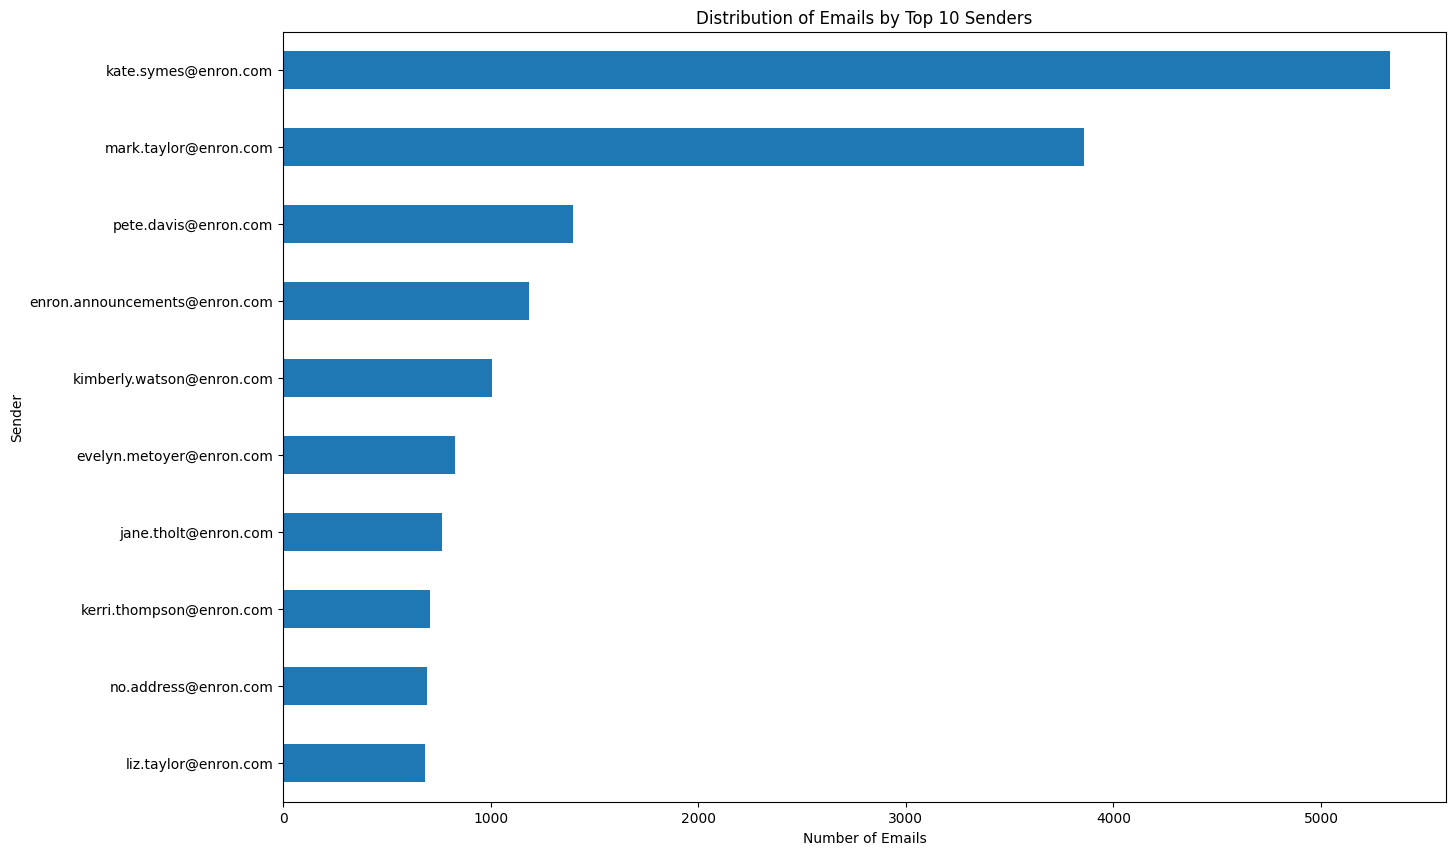

In [24]:
# Get the distribution of emails by sender
sender_distribution = email_df['From'].value_counts().head(10)  # Top 10 senders

# Plot horizontal bar chart for the top 10 senders
plt.figure(figsize=(15, 10))
sender_distribution.plot(kind='barh')
plt.title('Distribution of Emails by Top 10 Senders')
plt.xlabel('Number of Emails')
plt.ylabel('Sender')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.show()


The most active senders are kate.symes@enron.com and mark.taylor@enron.com, followed by pete.davis@enron.com

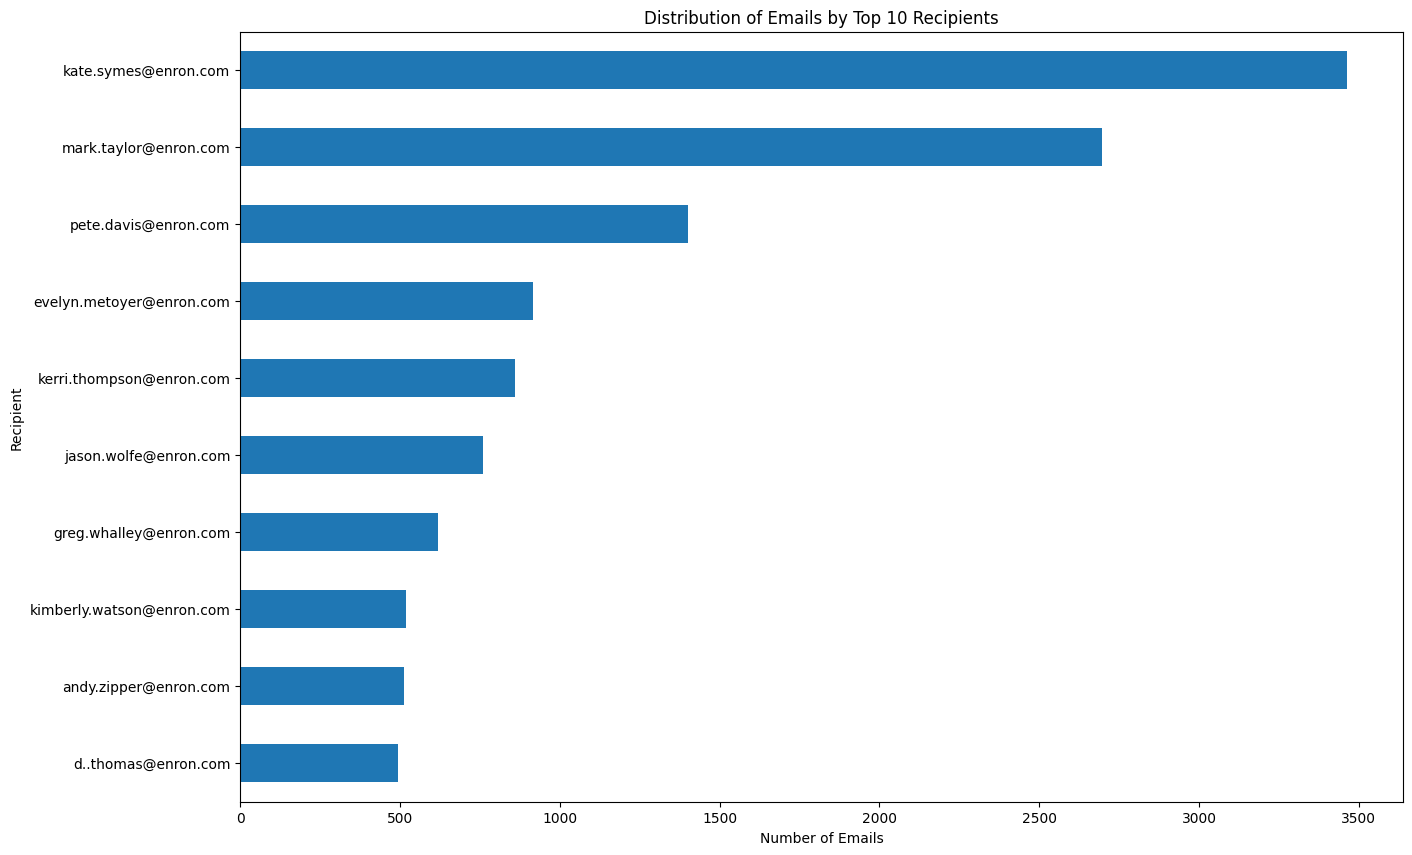

In [25]:
# Get the distribution of emails by recipient
recipient_distribution = email_df['To'].explode().value_counts().head(10)  # Top 10 recipients

# Plot horizontal bar chart for the top 10 recipients
plt.figure(figsize=(15, 10))
recipient_distribution.plot(kind='barh')
plt.title('Distribution of Emails by Top 10 Recipients')
plt.xlabel('Number of Emails')
plt.ylabel('Recipient')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.show()


Similar to the sender distribution, the most frequently contacted recipients are kate.symes@enron.com and mark.taylor@enron.com, followed by pete.davis@enron.com

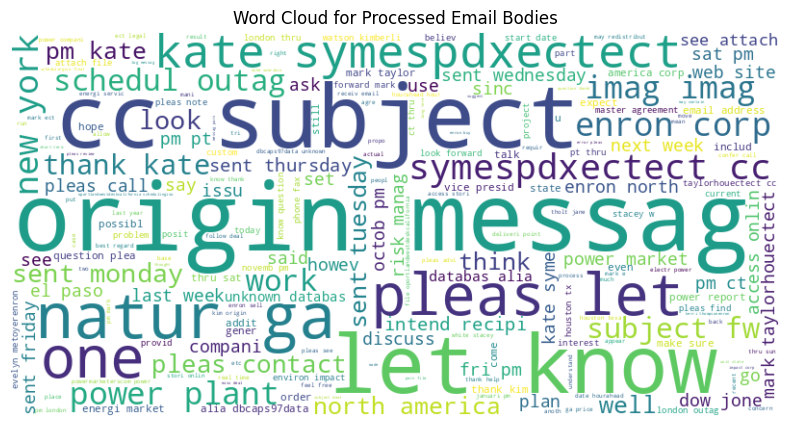

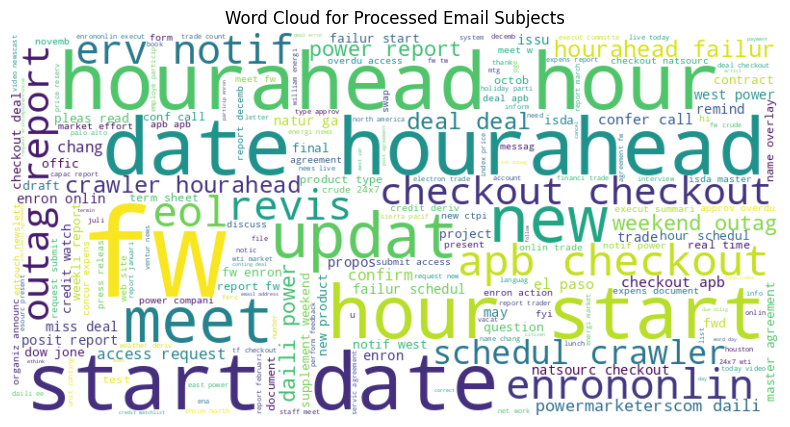

In [26]:
from wordcloud import WordCloud

# Generate word cloud for processed email bodies
body_text = ' '.join(email_df['Processed_Body'].dropna())
wordcloud_body = WordCloud(width=800, height=400, background_color='white').generate(body_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_body, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Processed Email Bodies')
plt.show()

# Generate word cloud for processed email subjects
subject_text = ' '.join(email_df['Processed_Subject'].dropna())
wordcloud_subject = WordCloud(width=800, height=400, background_color='white').generate(subject_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_subject, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Processed Email Subjects')
plt.show()


The most frequently used words suggest that mainly scheduling, organizing and power market related topics are discussed. 

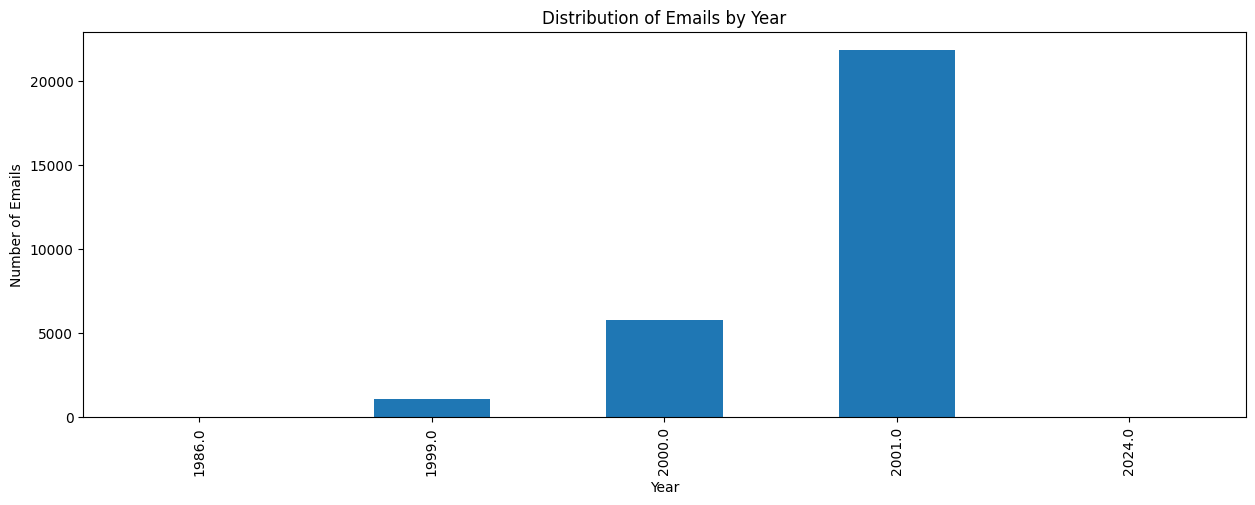

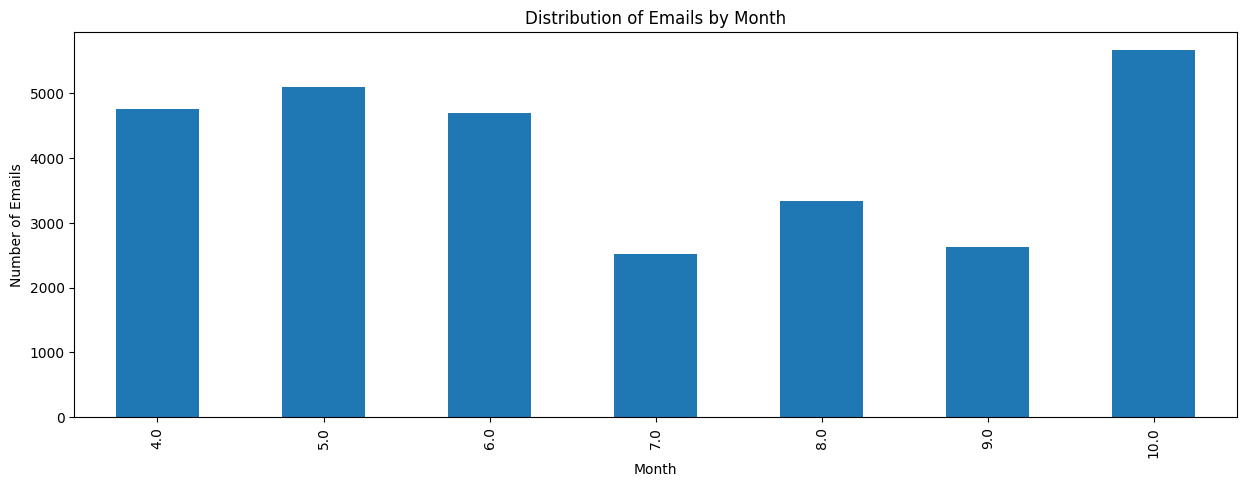

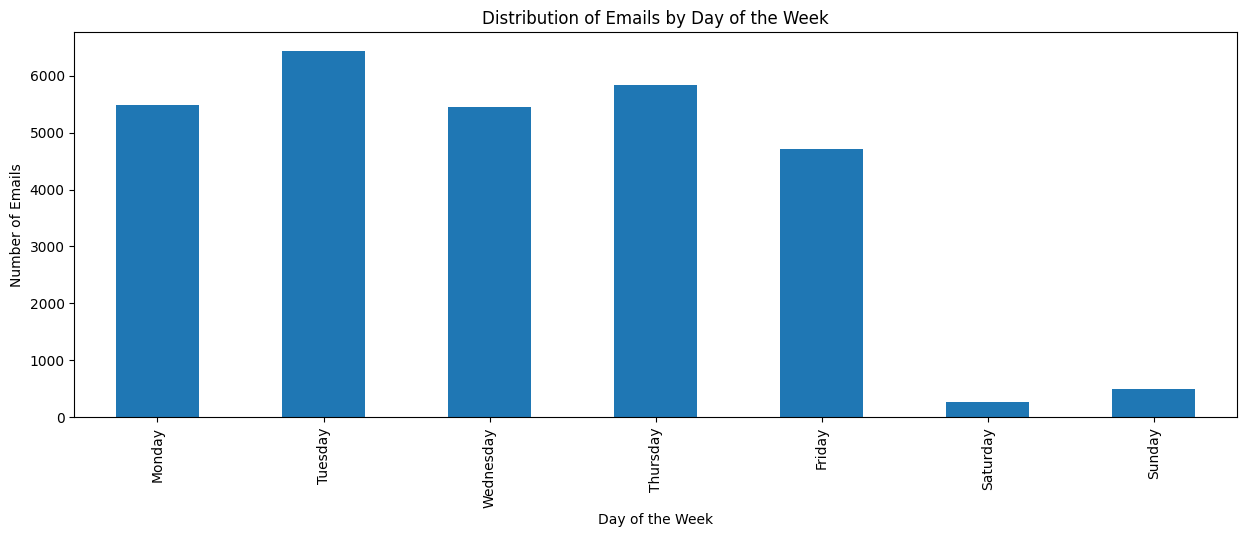

In [27]:
# Plot distribution of emails by year
plt.figure(figsize=(15, 5))
email_df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Emails by Year')
plt.xlabel('Year')
plt.ylabel('Number of Emails')
plt.show()

# Plot distribution of emails by month
plt.figure(figsize=(15, 5))
email_df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Emails by Month')
plt.xlabel('Month')
plt.ylabel('Number of Emails')
plt.show()

# Plot distribution of emails by day of the week
plt.figure(figsize=(15, 5))
email_df['DayOfWeek'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Emails by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Emails')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()


Most emails were sent in the year 2001. There are emails from 1986, 1999 and 2024, which might be anomalies or incorrectly dated emails. We can either mark them for further analysis or we can remove them. Email activity is relatively high in April, May, June and October. Email activity is high on Tuesdays and Thursdays. Few emails were sent on weekend. 

In [28]:
anomalous_dates = email_df[email_df['Year'].isin([1986, 2024])]
anomalous_dates
# Remove these emails for the sake of simplicity:
email_df = email_df[(email_df['Year'] >= 1998) & (email_df['Year'] <= 2003)]

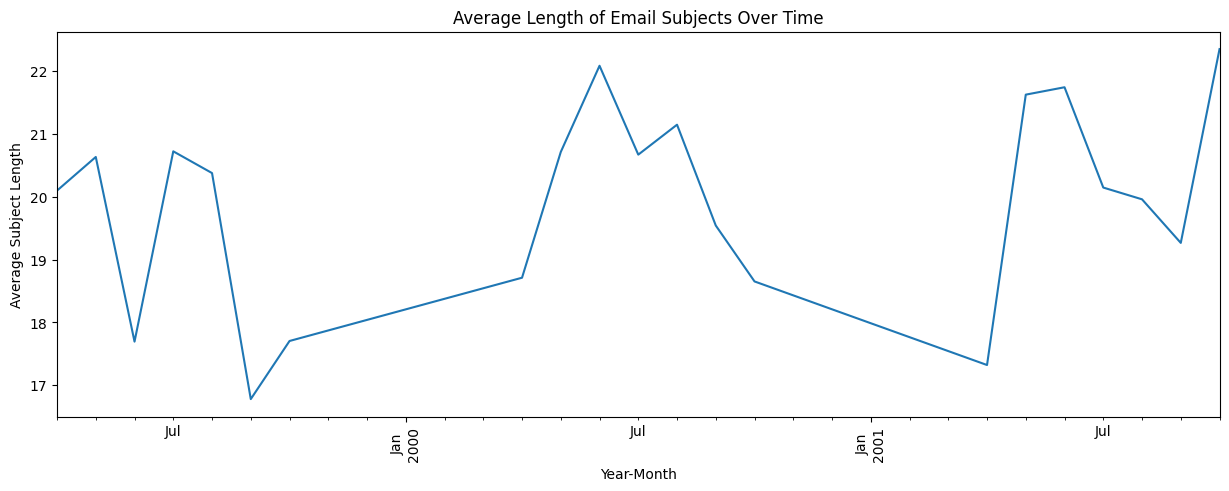

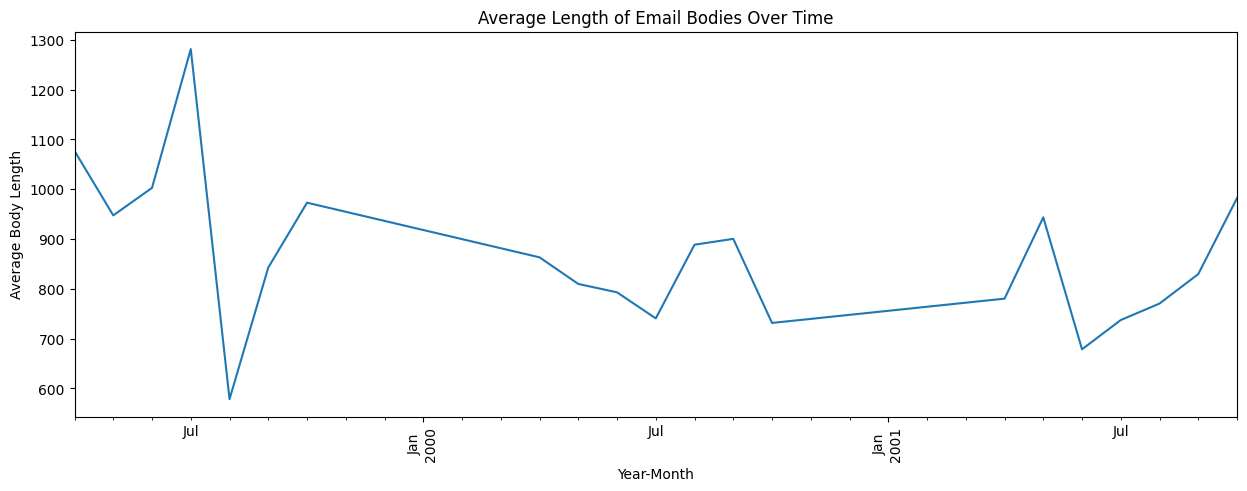

In [29]:
# Plot the trend of subject length over time
plt.figure(figsize=(15, 5))
email_df.groupby('YearMonth')['Subject_Length'].mean().plot()
plt.title('Average Length of Email Subjects Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Subject Length')
plt.xticks(rotation=90)
plt.show()

# Plot the trend of body length over time
plt.figure(figsize=(15, 5))
email_df.groupby('YearMonth')['Body_Length'].mean().plot()
plt.title('Average Length of Email Bodies Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Body Length')
plt.xticks(rotation=90)
plt.show()

Email subject length peaks around Jul 2000 and end of 2001. It has both increasing and decreasing trends.
Email body length peaks late 1999, afterwards, the average length decreases significantly

In [30]:
email_df.reset_index(inplace=True)

In [12]:
email_df['Sender_Domain'] = email_df['From'].apply(lambda x: x.split('@')[-1] if pd.notnull(x) else '')
email_df['Sender'] = email_df['From'].apply(lambda x: x.split('@')[0] if pd.notnull(x) else '')
email_df['To_Domains'] = email_df['To'].apply(lambda x: ','.join([email.split('@')[-1] for email in x.split(',')]) if pd.notnull(x) else '')
email_df['To_Users'] = email_df['To'].apply(lambda x: ','.join([email.split('@')[0] for email in x.split(',')]) if pd.notnull(x) else '')
email_df['Cc_Domains'] = email_df['Cc'].apply(lambda x: ','.join([email.split('@')[-1] for email in x.split(',')]) if pd.notnull(x) else '')
email_df['Cc_Users'] = email_df['Cc'].apply(lambda x: ','.join([email.split('@')[0] for email in x.split(',')]) if pd.notnull(x) else '')


In [13]:
# Determine the max_features parameter :

# Combine processed body and subject for vectorization
combined_text = email_df['Processed_Body'] + ' ' + email_df['Processed_Subject']

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(combined_text)

# Get the number of unique words
num_unique_words = len(tfidf_vectorizer.get_feature_names_out())
num_unique_words

162338

In [14]:
# Choose 2% of the unique words as max features
max_features = int(0.02 * num_unique_words)
max_features

3246

In [17]:
# Initialize the TF-IDF Vectorizer with the selected number of max features. This resulted in irrelevant words in the feature set. Therefore, top 500 is selected
tfidf_vectorizer = TfidfVectorizer(max_features=500)

# Fit and transform the combined text
tfidf_matrix = tfidf_vectorizer.fit_transform(combined_text)

# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())



# Initialize LabelEncoder
label_encoders = {}

# List of categorical columns to encode
categorical_columns = ['Sender', 'Sender_Domain', 'To_Users', 'To_Domains', 'Cc_Users', 'Cc_Domains']

# Apply LabelEncoder to each categorical column
for col in categorical_columns:
    le = LabelEncoder()
    email_df[col] = le.fit_transform(email_df[col].astype(str))
    label_encoders[col] = le

features_df = pd.concat([
    email_df[['Subject_Length', 'Body_Length', 'Num_Recipients', 'Has_Cc', 'Year', 'Month', 'DayOfWeek']],
    email_df['Sender'], email_df['Sender_Domain'],
    email_df['To_Users'], email_df['To_Domains'],
    email_df['Cc_Users'], email_df['Cc_Domains'],
    tfidf_df
], axis=1)

In [18]:


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Number of clusters (this can be tuned)
num_clusters = 20

# Initialize and fit KMeans
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(features_df)

# Assign cluster labels to each email
email_df['Cluster'] = kmeans.labels_

# Visualize the clusters
sns.countplot(x='Cluster', data=email_df)
plt.title('Cluster Distribution')
plt.show()

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [35]:
# Encode categorical features
for col in ['Sender', 'Sender_Domain', 'To_Users', 'To_Domains', 'Cc_Users', 'Cc_Domains']:
    le = LabelEncoder()
    features_df[col] = le.fit_transform(features_df[col].astype(str))

In [36]:
X = features_df
y = email_df['Level_1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf_1 = RandomForestClassifier(random_state=42)
clf_1.fit(X_train, y_train)
y_pred_1 = clf_1.predict(X_test)


             Feature  Importance
4               Year    0.047793
7             Sender    0.047251
9           To_Users    0.034754
5              Month    0.033103
275             mark    0.023821
244             kate    0.022445
10        To_Domains    0.020049
1        Body_Length    0.016966
247              kim    0.014561
0     Subject_Length    0.014414
8      Sender_Domain    0.011513
123             deal    0.011308
2     Num_Recipients    0.010968
254            legal    0.010791
6          DayOfWeek    0.009176
78              chri    0.008649
429           stacey    0.008405
58              bill    0.007817
248         kimberli    0.007533
458            thank    0.007450
72                cc    0.007253
342            pleas    0.006638
450           taylor    0.006571
11          Cc_Users    0.006324
200             greg    0.006257
318           origin    0.005824
282           messag    0.005820
439          subject    0.005707
326             paul    0.005271
466       

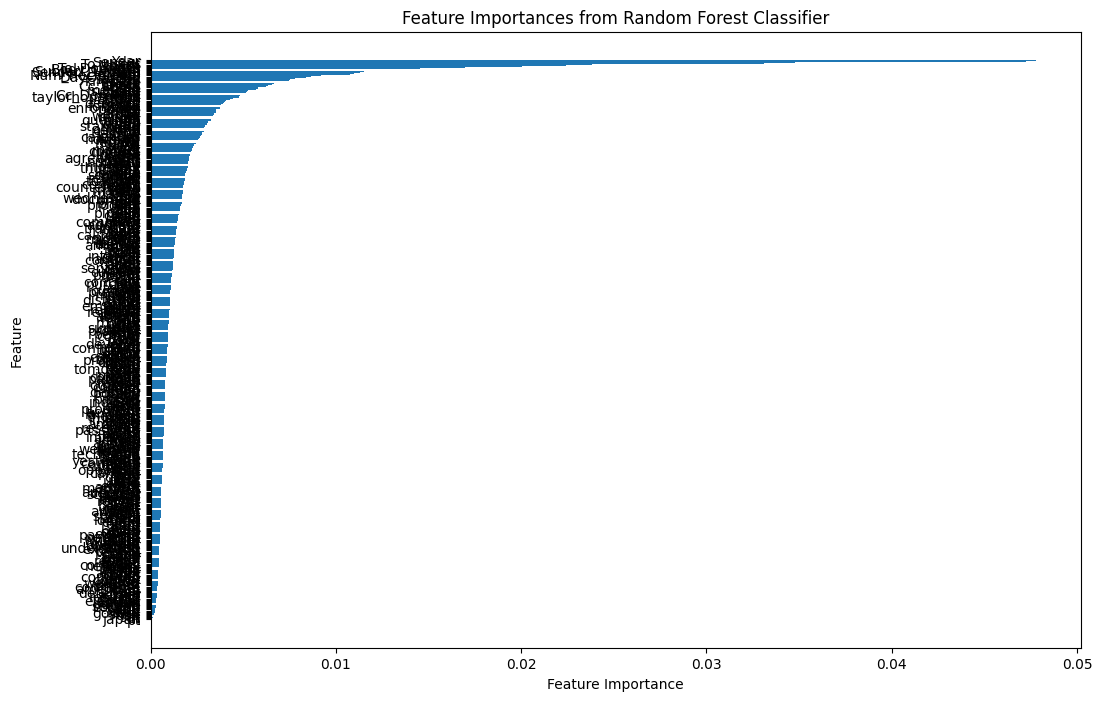

In [37]:
# Extract feature importances
feature_importances = clf_1.feature_importances_
features = X.columns

feature_importances_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Print the feature importances
print(feature_importances_df)

# Plot the feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest Classifier')
plt.gca().invert_yaxis()
plt.show()

In [38]:
# Evaluate the model for Level 1
accuracy_1 = accuracy_score(y_test, y_pred_1)
report_1 = classification_report(y_test, y_pred_1)

print(f"Level 1 - Accuracy: {accuracy_1}")
print("Level 1 - Classification Report:")
print(report_1)

Level 1 - Accuracy: 0.8259278619968635
Level 1 - Classification Report:
              precision    recall  f1-score   support

   stokley-c       0.86      0.89      0.87       158
    storey-g       0.57      0.41      0.47        74
     sturm-f       0.93      0.74      0.82       114
  swerzbin-m       0.62      0.29      0.40        17
     symes-k       0.94      0.98      0.96       526
    taylor-m       0.86      0.98      0.91      1667
     tholt-j       0.84      0.80      0.82       173
    thomas-p       0.75      0.59      0.66        94
  townsend-j       0.78      0.69      0.73        52
  tycholiz-b       0.73      0.49      0.59       175
      ward-k       0.90      0.86      0.88       264
    watson-k       0.85      0.82      0.84       224
    weldon-c       0.80      0.70      0.75       140
   whalley-g       0.50      0.48      0.49       225
   whalley-l       0.70      0.72      0.71       355
     white-s       0.93      0.92      0.93       360
     whit

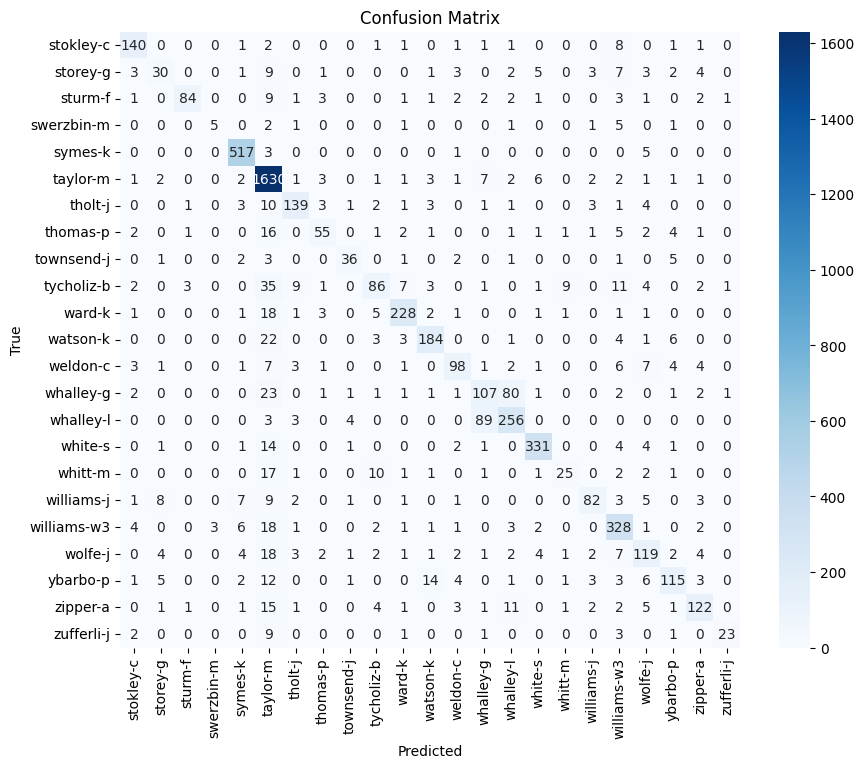

In [39]:
# Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

classes = email_df['Level_1'].unique()

plot_confusion_matrix(y_test, y_pred_1, classes)


# Task Description
In this project, a machine learning model was developed to classify emails into specific folders based on their content and metadata. A dataset of emails, including their manual folder assignments, was utilized to train and evaluate the model. The goal was to automate the email sorting process to reduce manual work.

# Data Processing

Folder structure consists of 6 hierarchical levels. An example folder structure: stokley-c/chris_stokley/projects/ees_/ercot/10.

Based on this structure, the first level was decided to be forecasted.

# Initial Analysis and Visualization

1. Distribution of Email count by Year and Month
   1. It showed the volume of emails over time with trends and spikes 
2. Folder Distribution
   1. This plot highlighted the most common folders and helped me to understand the distribution of emails across folders
3. Email Length Analysis
   1. This is done to understand the variability in the email content
4. Number of Recipients
   1. This is done to see how often emails were sent to multiple people
   
# Fature Extraction 

Text processing was used to utilize the email content. TF-IDF vectorization is used to represent email content with numbers.

In addition to that, Subject and Body length, Number of Recipients and CC indicator were used in the feature set. 

Moreover, some meta data was also included such as sender and recipient information

# Model Training 

Random forest is used due to handle large number of features and the ease of interpretability.

# Evaluation
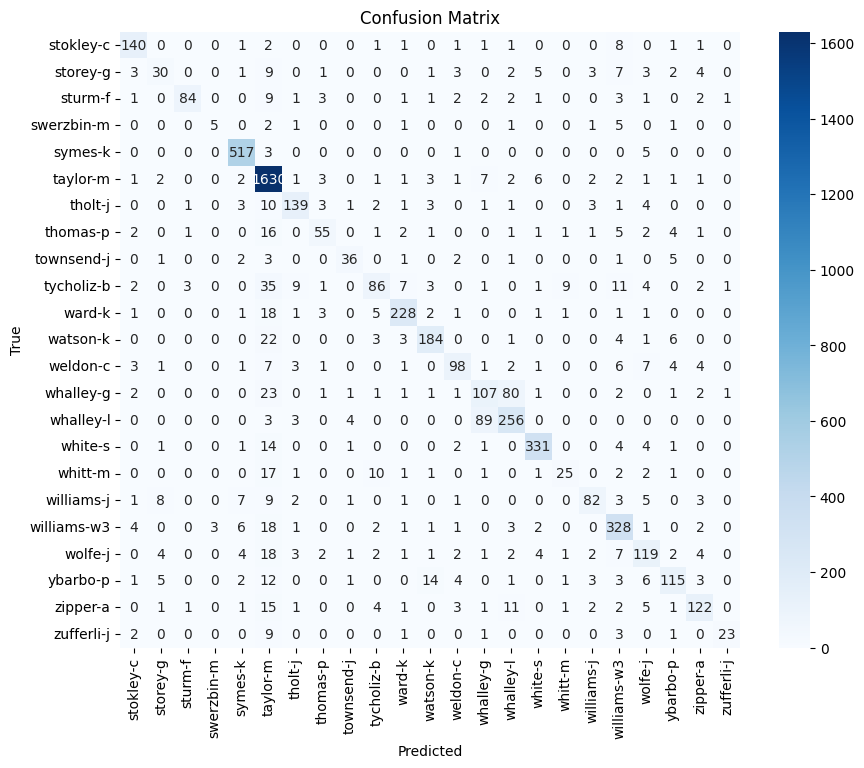

The overall accuracy of the model is 0.8259. This indicates that the model correctly predicts the folder for about 82.6% of the emails in the test set.

Some folders such as symes-k (F1-score: 0.96), taylor-m (F1-score: 0.91), and white-s (F1-score: 0.93) show high performance in terms of precision, recall, and F1-score

Some low performing classes: 
swerzbin-m: This class has a low F1-score of 40%, with precision (62%) and recall (29%). The model struggles with both capturing relevant emails and avoiding false positives, indicating a need for more data or better feature engineering for this class.

# Key Insights
Features should have analyzed together with the target variable to understand their correlation better and to select the most relevant feature set.This could have improved the model performance.

The same training process should be repeated to determine all the subfolders. However, given the number of unique subfolders in level 2 and level 3,  a different approach might be needed

Oversampling could be done to balance the class imbalances to improve the model performance
